In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

base_dir = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))

# CSV paths
diagnoses_path = os.path.join(base_dir, "data", "diagnoses.csv")
patients_path  = os.path.join(base_dir, "data", "patients.csv")
outcomes_path  = os.path.join(base_dir, "data", "outcomes.csv")

from src.data_pipeline import load_and_merge_data, clean_and_impute
from src.features import engineer_features

# Loading and prepping data
df = load_and_merge_data(diagnoses_path, patients_path, outcomes_path)
admitted = clean_and_impute(df)
X, y, feature_cols = engineer_features(admitted)

# Reattaching the target for EDA
admitted = X.copy()
admitted["readmitted_30d"] = y
target = "readmitted_30d"

Shape after merge: (274592, 45)
Admitted patients: 34516
Readmission rate:  16.2%



Class distribution:
readmitted_30d
0.0    28921
1.0     5595
Name: count, dtype: int64
Imbalance ratio: 5.2:1


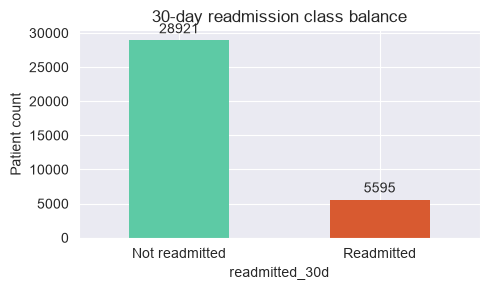

In [13]:
counts = admitted[target].value_counts()
print(f"\nClass distribution:\n{counts}")
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind="bar", ax=ax, color=["#5DCAA5", "#D85A30"], edgecolor="none")
ax.set_xticklabels(["Not readmitted", "Readmitted"], rotation=0)
ax.set_ylabel("Patient count")
ax.set_title("30-day readmission class balance")
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

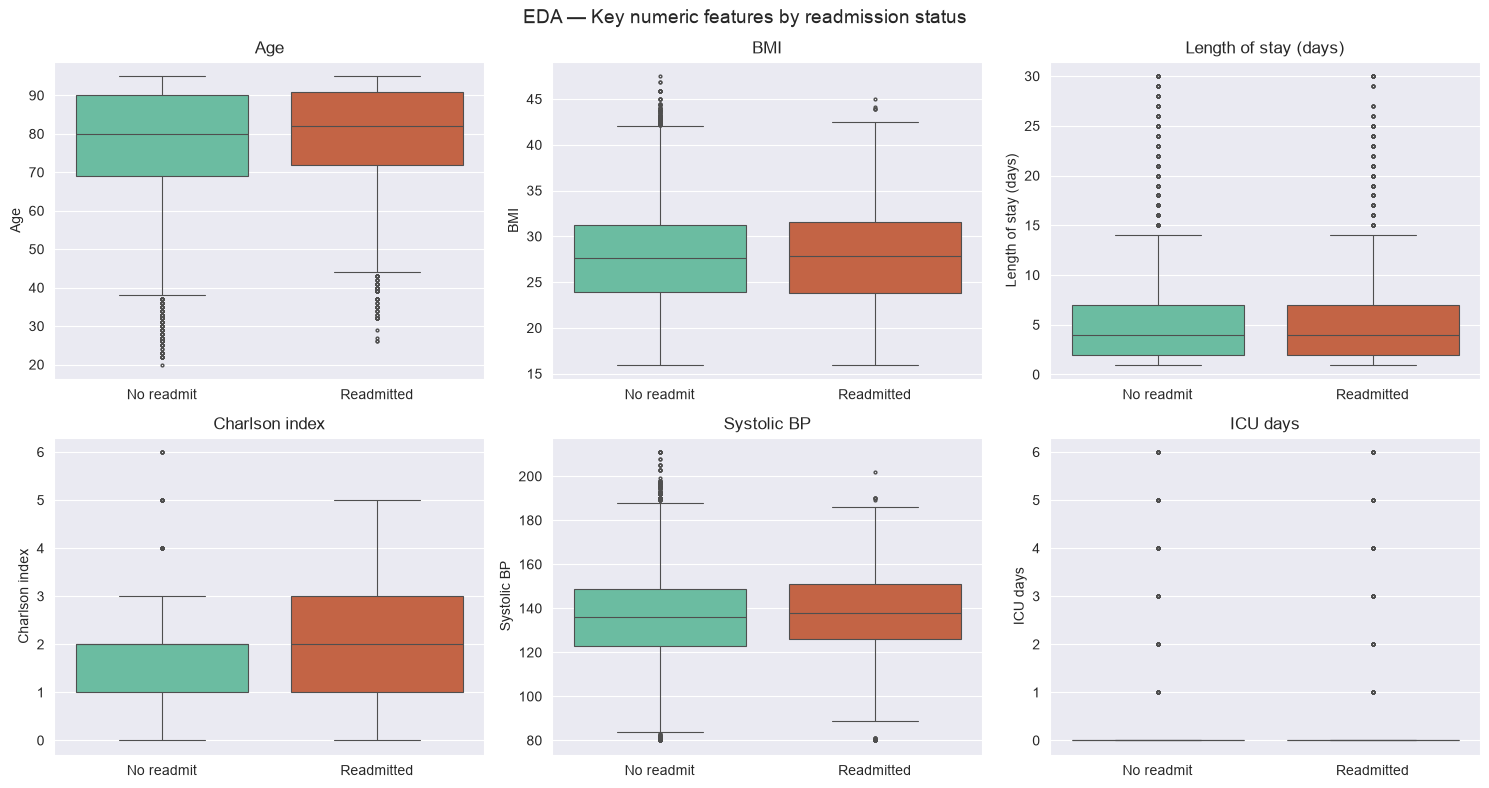

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("EDA — Key numeric features by readmission status", fontsize=14)

plot_cols = [
    ("age",                 "Age"),
    ("bmi",                 "BMI"),
    ("length_of_stay_days", "Length of stay (days)"),
    ("charlson_index",      "Charlson index"),
    ("systolic_bp",         "Systolic BP"),
    ("icu_days",            "ICU days"),
]
for ax, (col, label) in zip(axes.flat, plot_cols):
    sns.boxplot(
        data=admitted, x=target, y=col, ax=ax,
        palette=["#5DCAA5", "#D85A30"],
        linewidth=0.8, fliersize=2,
    )
    ax.set_xlabel("")
    ax.set_xticklabels(["No readmit", "Readmitted"])
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.show()

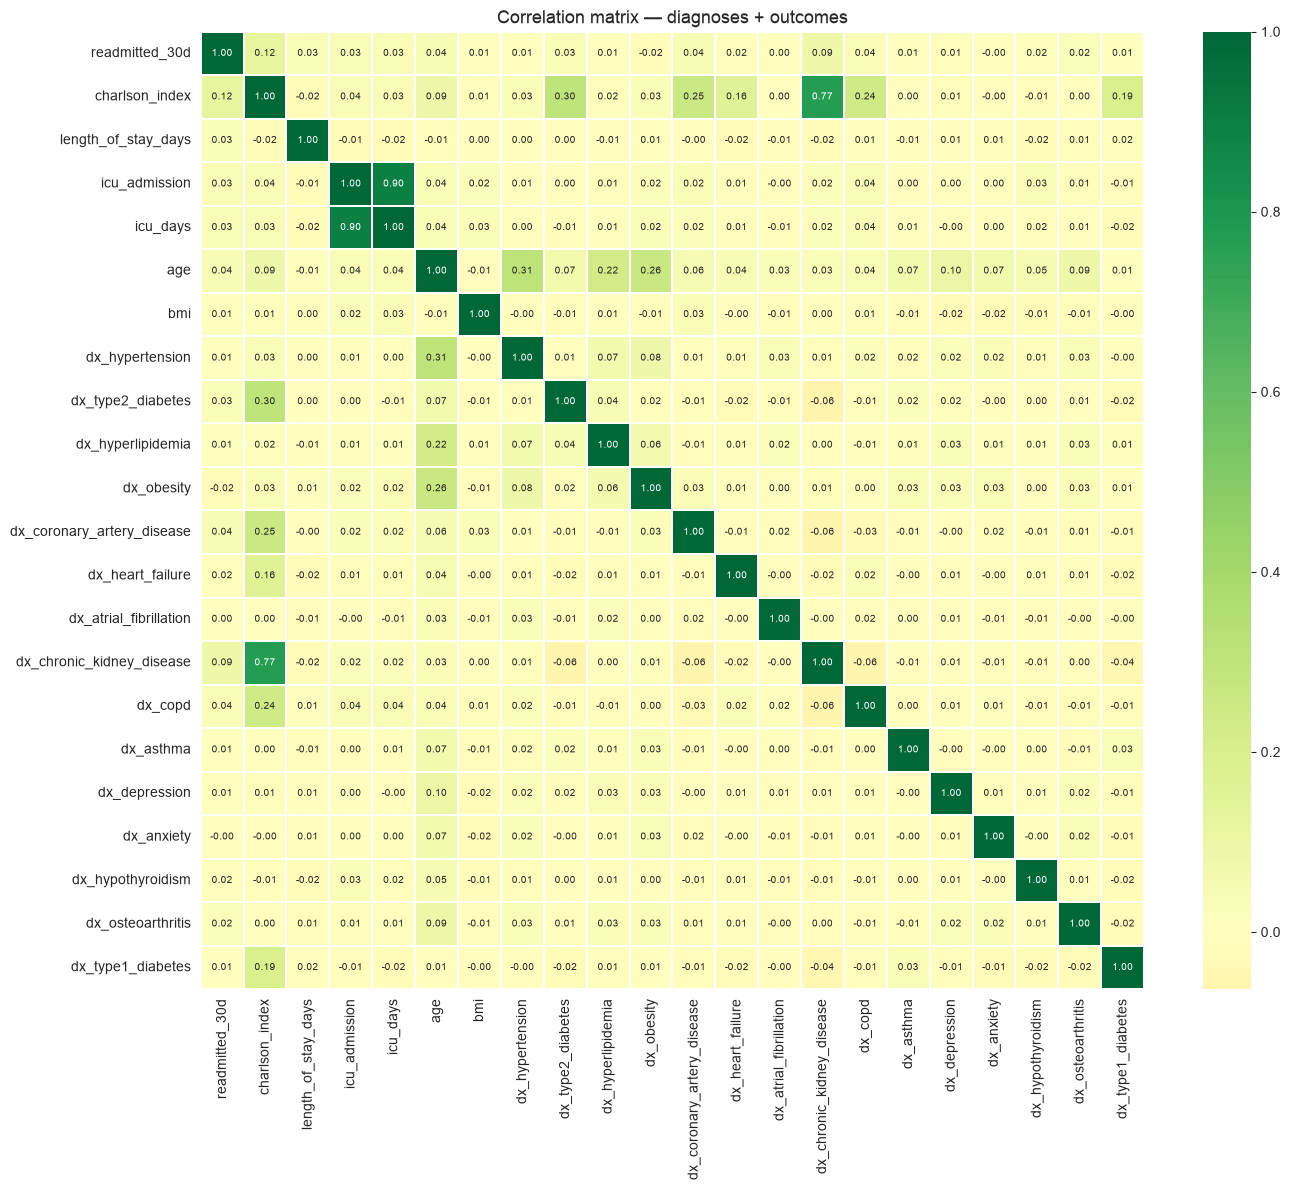

In [15]:
dx_cols = [c for c in admitted.columns if c.startswith("dx_")]
heatmap_cols = (
    ["readmitted_30d", "charlson_index", "length_of_stay_days",
     "icu_admission", "icu_days", "age", "bmi"]
    + dx_cols
)
corr = admitted[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.3, linecolor="white",
    annot_kws={"size": 7}, ax=ax,
)
ax.set_title("Correlation matrix — diagnoses + outcomes", fontsize=13)
plt.tight_layout()
plt.show()

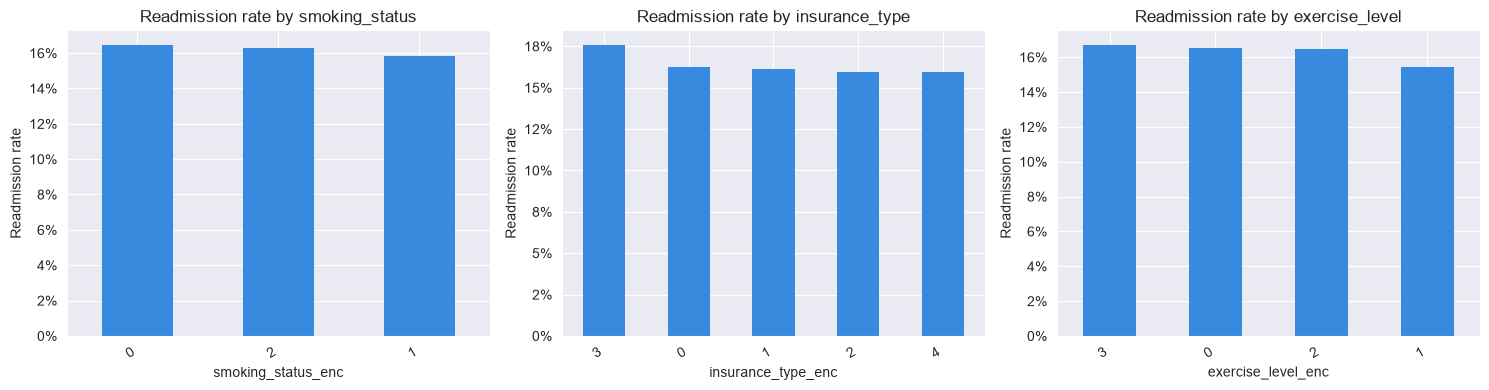

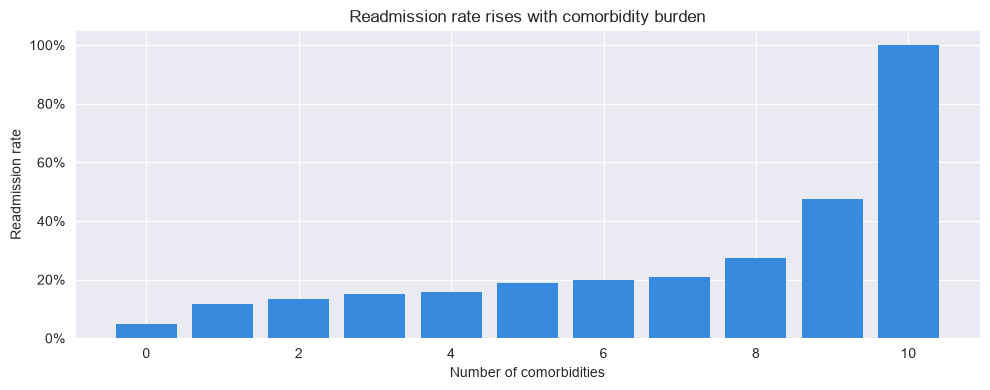

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Note: Using encoded columns since raw ones were replaced in the feature pipeline
for ax, col in zip(axes, ["smoking_status_enc", "insurance_type_enc", "exercise_level_enc"]):
    rate = admitted.groupby(col)["readmitted_30d"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#378ADD", edgecolor="none")
    ax.set_title(f"Readmission rate by {col.replace('_enc', '')}")
    ax.set_ylabel("Readmission rate")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

plt.tight_layout()
plt.show()

# Readmission rate by comorbidity count
fig, ax = plt.subplots(figsize=(10, 4))
rate_by_comorbidity = (
    admitted.groupby("num_comorbidities")["readmitted_30d"]
    .agg(["mean", "count"])
    .reset_index()
)
ax.bar(
    rate_by_comorbidity["num_comorbidities"],
    rate_by_comorbidity["mean"],
    color="#378ADD", edgecolor="none",
)
ax.set_xlabel("Number of comorbidities")
ax.set_ylabel("Readmission rate")
ax.set_title("Readmission rate rises with comorbidity burden")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()